100%|██████████| 500/500 [00:58<00:00,  8.54it/s]


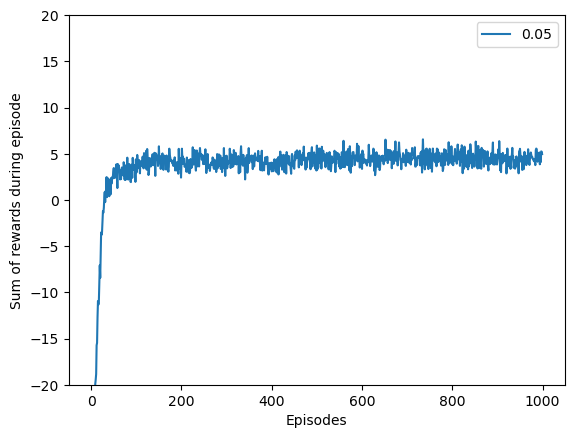

Q-Learning Optimal Policy:
['R', 'R', 'R', 'D']
['U', 'U', 'D', 'D']
['D', 'R', 'D', 'D']
['R', 'R', 'R', 'G']


In [11]:
#######################################################################
# Copyright (C)                                                       #
# 2016-2018 Shangtong Zhang(zhangshangtong.cpp@gmail.com)             #
# 2016 Kenta Shimada(hyperkentakun@gmail.com)                         #
# Permission given to modify the code as long as you keep this        #
# declaration at the top                                              #
#######################################################################

import numpy as np
import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt
from tqdm import tqdm

# world height
WORLD_HEIGHT = 4

# world width
WORLD_WIDTH = 4

# probability for exploration


# step size
ALPHA = 0.5

# gamma for Q-Learning and Expected Sarsa
GAMMA = 1

# all possible actions
ACTION_UP = 0
ACTION_DOWN = 1
ACTION_LEFT = 2
ACTION_RIGHT = 3
ACTIONS = [ACTION_UP, ACTION_DOWN, ACTION_LEFT, ACTION_RIGHT]

# initial state action pair values
START = [0, 0]
GOAL = [3, 3]

def step(state, action):
    i, j = state
    if action == ACTION_UP:
        next_state = [max(i - 1, 0), j]
    elif action == ACTION_LEFT:
        next_state = [i, max(j - 1, 0)]
    elif action == ACTION_RIGHT:
        next_state = [i, min(j + 1, WORLD_WIDTH - 1)]
    elif action == ACTION_DOWN:
        next_state = [min(i + 1, WORLD_HEIGHT - 1), j]
    else:
        assert False
    k, l =next_state
    reward = -1
    if (action == ACTION_DOWN and i == 2 and j==3) or (
        action == ACTION_RIGHT and i==3 and j==2):#winning
        reward = 20
        next_state = GOAL
    if (l==1): #ghost over 2nd column
        if np.random.binomial(1, 0.25) == 1:
            reward = -20
            next_state =GOAL
        else:
            next_state=next_state
    if (k==1 and 0<=l<3): #ghost over 2nd column
        if np.random.binomial(1, 0.33) == 1:
            reward = -20
            next_state =GOAL
        else:
            next_state=next_state
        

    return next_state, reward

# reward for each action in each state
# actionRewards = np.zeros((WORLD_HEIGHT, WORLD_WIDTH, 4))
# actionRewards[:, :, :] = -1.0
# actionRewards[2, 1:11, ACTION_DOWN] = -100.0
# actionRewards[3, 0, ACTION_RIGHT] = -100.0

# set up destinations for each action in each state
# actionDestination = []
# for i in range(0, WORLD_HEIGHT):
#     actionDestination.append([])
#     for j in range(0, WORLD_WIDTH):
#         destinaion = dict()
#         destinaion[ACTION_UP] = [max(i - 1, 0), j]
#         destinaion[ACTION_LEFT] = [i, max(j - 1, 0)]
#         destinaion[ACTION_RIGHT] = [i, min(j + 1, WORLD_WIDTH - 1)]
#         if i == 2 and 1 <= j <= 10:
#             destinaion[ACTION_DOWN] = START
#         else:
#             destinaion[ACTION_DOWN] = [min(i + 1, WORLD_HEIGHT - 1), j]
#         actionDestination[-1].append(destinaion)
# actionDestination[3][0][ACTION_RIGHT] = START

# choose an action based on epsilon greedy algorithm
def choose_action(state, q_value,epsilon):
    if np.random.binomial(1, epsilon) == 1:
        return np.random.choice(ACTIONS)
    else:
        values_ = q_value[state[0], state[1], :]
        return np.random.choice([action_ for action_, value_ in enumerate(values_) if value_ == np.max(values_)])

# an episode with Sarsa
# @q_value: values for state action pair, will be updated
# @expected: if True, will use expected Sarsa algorithm
# @step_size: step size for updating
# @return: total rewards within this episode
def sarsa(q_value, expected=False, step_size=ALPHA):
    state = START
    epsilon=0.5
    action = choose_action(state, q_value,epsilon)
    rewards = 0.0
    while state != GOAL:
        epsilon=max(0.001, epsilon* np.exp(-0.1))
        next_state, reward = step(state, action)
        next_action = choose_action(next_state, q_value,epsilon)
        rewards += reward
        if not expected:
            target = q_value[next_state[0], next_state[1], next_action]
        else:
            # calculate the expected value of new state
            target = 0.0
            q_next = q_value[next_state[0], next_state[1], :]
            best_actions = np.argwhere(q_next == np.max(q_next))
            for action_ in ACTIONS:
                if action_ in best_actions:
                    target += ((1.0 - EPSILON) / len(best_actions) + EPSILON / len(ACTIONS)) * q_value[next_state[0], next_state[1], action_]
                else:
                    target += EPSILON / len(ACTIONS) * q_value[next_state[0], next_state[1], action_]
        target *= GAMMA
        q_value[state[0], state[1], action] += step_size * (
                reward + target - q_value[state[0], state[1], action])
        state = next_state
        action = next_action
    return rewards

# an episode with Q-Learning
# @q_value: values for state action pair, will be updated
# @step_size: step size for updating
# @return: total rewards within this episode
def q_learning(q_value, epsilon, step_size=ALPHA):
    state = START
    rewards = 0.0
    while state != GOAL:
        
        action = choose_action(state, q_value,epsilon)
        next_state, reward = step(state, action)
        rewards += reward
        # Q-Learning update
        q_value[state[0], state[1], action] += step_size * (
                reward + GAMMA * np.max(q_value[next_state[0], next_state[1], :]) -
                q_value[state[0], state[1], action])
        state = next_state
    return rewards

# print optimal policy
def print_optimal_policy(q_value):
    optimal_policy = []
    for i in range(0, WORLD_HEIGHT):
        optimal_policy.append([])
        for j in range(0, WORLD_WIDTH):
            if [i, j] == GOAL:
                optimal_policy[-1].append('G')
                continue
            bestAction = np.argmax(q_value[i, j, :])
            if bestAction == ACTION_UP:
                optimal_policy[-1].append('U')
            elif bestAction == ACTION_DOWN:
                optimal_policy[-1].append('D')
            elif bestAction == ACTION_LEFT:
                optimal_policy[-1].append('L')
            elif bestAction == ACTION_RIGHT:
                optimal_policy[-1].append('R')
    for row in optimal_policy:
        print(row)

# Use multiple runs instead of a single run and a sliding window
# With a single run I failed to present a smooth curve
# However the optimal policy converges well with a single run
# Sarsa converges to the safe path, while Q-Learning converges to the optimal path
def figure_6_4():
    # episodes of each run
    episodes = 1000

    # perform 40 independent runs
    runs = 500
    epsilon=0.9
    rewards_q5 = np.zeros(episodes)
    #rewards_q10 = np.zeros(episodes)
    #rewards_q30 = np.zeros(episodes)
    for r in tqdm(range(runs)):
        q_5 = np.zeros((WORLD_HEIGHT, WORLD_WIDTH, 4))
        #q_10 = np.copy(q_5)
        #q_30 = np.copy(q_5)
        
        for i in range(0, episodes):
            #epsilon decay
            epsilon=max(0.01,epsilon*np.exp(-0.001)) 
            rewards_q5[i] += q_learning(q_5,epsilon)
            #rewards_q10[i] += q_learning(q_10,epsilon=0.10)
            #rewards_q30[i] += q_learning(q_30,epsilon=0.3)

    # averaging over independt runs
    rewards_q5 /= runs
    #rewards_q10 /= runs
    #rewards_q30 /= runs

    # draw reward curves
    plt.plot(rewards_q5, label='0.05')
    #plt.plot(rewards_q10, label='0.10')
    #plt.plot(rewards_q30, label='0.30')
    plt.xlabel('Episodes')
    plt.ylabel('Sum of rewards during episode')
    plt.ylim([-20, 20])
    plt.legend()
    plt.show()

    #plt.savefig('../images/figure_6_4.png')
    plt.close()

    # display optimal policy
    #print('Sarsa Optimal Policy:')
    #print_optimal_policy(q_sarsa)
    print('Q-Learning Optimal Policy:')
    print_optimal_policy(q_5)

if __name__ == '__main__':
    figure_6_4()

100%|██████████| 50/50 [00:29<00:00,  1.69it/s]


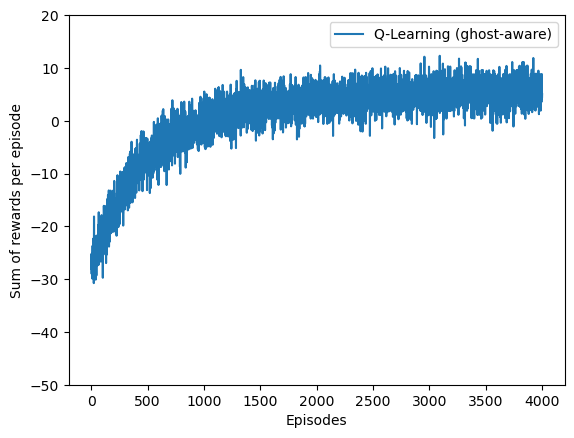

Q-Learning Optimal Policy:
[[[ 13.74451249  13.01899898  13.06917152 -16.91538092]
  [  0.           0.           0.           0.        ]
  [ 16.          17.          12.06632515  17.        ]
  [ 17.          18.          16.          17.        ]]

 [[ 13.96621121  15.99942768  13.86891567 -16.82128507]
  [-12.38504514  17.          14.49843322  17.        ]
  [ 16.          18.          15.77195321  18.        ]
  [ 17.          19.          17.          18.        ]]

 [[ 14.79741446  17.          15.23082008  17.        ]
  [-19.09524496  18.          15.94476417  18.        ]
  [ 17.          19.          17.          19.        ]
  [ 18.          20.          18.          19.        ]]

 [[ 15.88271776  17.          17.          18.        ]
  [ 17.          18.          17.          19.        ]
  [ 18.          19.          18.          20.        ]
  [  0.           0.           0.           0.        ]]]
['U', 'U', 'D', 'D'] 0
['D', 'D', 'D', 'D'] 0
['D', 'D', 'D', 'D'] 0


In [30]:
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from tqdm import tqdm
# Grid world size
WORLD_HEIGHT = 4
WORLD_WIDTH = 4

# Q-learning parameters
ALPHA = 0.7
GAMMA = 1

# Actions
ACTION_UP = 0
ACTION_DOWN = 1
ACTION_LEFT = 2
ACTION_RIGHT = 3
ACTIONS = [ACTION_UP, ACTION_DOWN, ACTION_LEFT, ACTION_RIGHT]

# Start, goal, and ghost positions
START = [0, 0]
GSTART = [2, 1]
GOAL = [3, 3]

def step(state, action, ghost):
    i, j = state
    if action == ACTION_UP:
        next_state = [max(i - 1, 0), j]
    elif action == ACTION_LEFT:
        next_state = [i, max(j - 1, 0)]
    elif action == ACTION_RIGHT:
        next_state = [i, min(j + 1, WORLD_WIDTH - 1)]
    elif action == ACTION_DOWN:
        next_state = [min(i + 1, WORLD_HEIGHT - 1), j]
    else:
        raise ValueError("Invalid action")

    k, l = next_state
    reward = -1
    x, y = ghost

    # Ghost movement logic
    if x == 0:
        nghost = [0, y] if np.random.rand() < 0.5 else [1, y]
    elif x == 1:
        r = np.random.rand()
        if r < 0.33:
            nghost = [1, y]
        elif r < 0.67:
            nghost = [0, y]
        else:
            nghost = [2, y]
    elif x == 2:
        r = np.random.rand()
        if r < 0.33:
            nghost = [2, y]
        elif r < 0.67:
            nghost = [1, y]
        else:
            nghost = [3, y]
    elif x == 3:
        nghost = [2, y] if np.random.rand() < 0.5 else [3, y]

    # Winning condition
    if (action == ACTION_DOWN and i == 2 and j == 3) or (action == ACTION_RIGHT and i == 3 and j == 2):
        reward = 20
        next_state = GOAL

    # Losing condition (collision with ghost)
    if nghost == next_state:
        reward = -20
        next_state = GOAL
    return next_state, reward, nghost

def choose_action(state, ghost, q_value, epsilon):
    #Chooses an action using the epsilon-greedy policy, considering the ghost's position.
    ghost_index = ghost[1]  # Ghost moves along the second index (y-coordinate)

    if np.random.rand() < epsilon:
        return np.random.choice(ACTIONS)
    else:
        values_ = q_value[state[0], state[1], ghost_index, :]
        return np.random.choice([action_ for action_, value_ in enumerate(values_) if value_ == np.max(values_)])

def q_learning(q_value, epsilon, step_size=ALPHA):
    state = START
    ghost = GSTART
    rewards = 0.0
    while state != GOAL:
        ghost_index = ghost[0]  # Ghost position for Q-table indexing
        action = choose_action(state, ghost, q_value, epsilon)
        next_state, reward, ghost = step(state, action, ghost)
        next_ghost_index = ghost[0]  # Update ghost position index

        rewards += reward
        # Q-Learning update considering ghost position
        q_value[state[0], state[1], ghost_index, action] += step_size * (
            reward + GAMMA * np.max(q_value[next_state[0], next_state[1], next_ghost_index, :]) - 
            q_value[state[0], state[1], ghost_index, action]
        )
        state = next_state
    return rewards

def print_optimal_policy(q_value):
    for k in (0,1,2,3):
        print(q_value[:, :, k, :])
        optimal_policy = []
        for i in range(0, WORLD_HEIGHT):
            optimal_policy.append([])
            for j in range(0, WORLD_WIDTH):
                if [i, j] == GOAL:
                    optimal_policy[-1].append('G')
                    continue
                bestAction = np.argmax(q_value[i, j, k, :])
                if bestAction == ACTION_UP:
                    optimal_policy[-1].append('U')
                elif bestAction == ACTION_DOWN:
                    optimal_policy[-1].append('D')
                elif bestAction == ACTION_LEFT:
                    optimal_policy[-1].append('L')
                elif bestAction == ACTION_RIGHT:
                    optimal_policy[-1].append('R')
        for row in optimal_policy:
            print(row,k)
def figure_6_4():
    episodes = 4000
    runs = 50
    #epsilon = 1
    rewards_q5 = np.zeros(episodes)

    # Q-table now has an extra dimension for ghost positions
    q_5 = np.zeros((WORLD_HEIGHT, WORLD_WIDTH, 4, 4))  # [grid_x, grid_y, ghost_y, actions]

    for r in tqdm(range(runs)):
        epsilon=1
        for i in range(episodes):
            epsilon = max(0.001, epsilon * np.exp(-0.001))  # Epsilon decay
            rewards_q5[i] += q_learning(q_5, epsilon)

    rewards_q5 /= runs

    # Plot reward curves
    plt.plot(rewards_q5, label='Q-Learning (ghost-aware)')
    plt.xlabel('Episodes')
    plt.ylabel('Sum of rewards per episode')
    plt.ylim([-50, 20])
    plt.legend()
    plt.show()

    print('Q-Learning Optimal Policy:')
    print_optimal_policy(q_5)

if __name__ == '__main__':
    figure_6_4()
#q_learning(np.zeros((WORLD_HEIGHT, WORLD_WIDTH, 4, 4)), 0.1, step_size=ALPHA)




